# Observer Transformer: Complete Architecture Test

This notebook implements and tests all three tiers of the Observer Transformer architecture on CIFAR-10.

**What this notebook does:**
- **Tier 1:** Drop-in hyperparameter changes (dropout=0.382, FFN expansion=2.618x) applied to a standard ViT
- **Tier 2:** Inter-head message passing on a hypercube graph with mixing rate alpha=0.382
- **Tier 3:** Full Observer Transformer with dual-channel (MVSU) attention and inhibitory cross-correction

**How to use:** Open in Google Colab (or any Jupyter environment), select a GPU runtime if available, and click "Run All".

**Expected runtime:** ~15-30 min on Colab GPU, ~30-60 min on CPU (with reduced configs).

## Theory Recap

The Observer Transformer is built on a single theoretical insight: in any system that processes information AND must account for its own effect on that information (residual connections, autoregressive generation, self-play), the optimal fraction of capacity devoted to redundancy/regularization is **1/phi^2 = 0.382**, where phi = (1+sqrt(5))/2 is the golden ratio.

This comes from requiring the partition between content (fraction x) and structure/redundancy (fraction 1-x) to be **self-similar**: (1-x)/x = x/1, giving x^2 + x - 1 = 0, with solution x = 1/phi = 0.618.

### The Three Predictions

| ML Concept | Standard Default | Predicted Optimal | Rationale |
|------------|-----------------|-------------------|----------|
| Dropout rate | 0.5 | **0.382** | Redundancy fraction = 1/phi^2 |
| FFN expansion | 4x | **2.618x** (phi^2) | Total/content = 1/(1-0.382) |
| Inter-head mixing | None or dense | **0.382 on hypercube** | Neighbor update fraction |

For full theory: see the Observer Transformer Architecture Specification.

---
## Section 0: Setup
### Imports

In [1]:
import math
import time
import copy
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Use a clean plot style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        pass  # Fall back to default style

# Constants
PHI = (1 + 5 ** 0.5) / 2   # 1.618...
PHI_SQ = PHI ** 2           # 2.618...
PHI_INV_SQ = 1 / PHI_SQ    # 0.382...

print(f"phi = {PHI:.6f}")
print(f"phi^2 = {PHI_SQ:.6f}")
print(f"1/phi^2 = {PHI_INV_SQ:.6f}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

phi = 1.618034
phi^2 = 2.618034
1/phi^2 = 0.381966
PyTorch version: 2.9.0+cu128
Torchvision version: 0.24.0+cu128


### Device Detection & Configuration

Auto-detect GPU availability and set model/training hyperparameters accordingly. On CPU we use smaller models and less data to keep runtime reasonable.

In [2]:
# ----- Device detection -----
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    GPU_NAME = torch.cuda.get_device_name(0)
    print(f"GPU detected: {GPU_NAME}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    GPU_NAME = 'Apple MPS'
    print(f"MPS detected (Apple Silicon)")
else:
    DEVICE = torch.device('cpu')
    GPU_NAME = None
    print("No GPU detected -- using CPU (reduced configs)")

USE_GPU = DEVICE.type in ('cuda', 'mps')

# ----- Configuration based on device -----
if USE_GPU:
    D_MODEL = 128
    NUM_LAYERS = 4
    NUM_HEADS = 8
    HEAD_DIM = D_MODEL // NUM_HEADS  # 16
    SECONDARY_RANK = 16
    BATCH_SIZE = 128
    NUM_EPOCHS = 20
    ALPHA_SWEEP_EPOCHS = 8
    TRAIN_SUBSET = None   # Use full CIFAR-10 (50k)
    TEST_SUBSET = None    # Use full test set (10k)
    print(f"\nGPU config: d_model={D_MODEL}, layers={NUM_LAYERS}, heads={NUM_HEADS}, epochs={NUM_EPOCHS}")
else:
    D_MODEL = 64
    NUM_LAYERS = 2
    NUM_HEADS = 8
    HEAD_DIM = D_MODEL // NUM_HEADS  # 8
    SECONDARY_RANK = 8
    BATCH_SIZE = 128
    NUM_EPOCHS = 10
    ALPHA_SWEEP_EPOCHS = 5
    TRAIN_SUBSET = 5000
    TEST_SUBSET = 2000
    print(f"\nCPU config: d_model={D_MODEL}, layers={NUM_LAYERS}, heads={NUM_HEADS}, epochs={NUM_EPOCHS}")
    print(f"Using subset: {TRAIN_SUBSET} train, {TEST_SUBSET} test")

PATCH_SIZE = 4
IMG_SIZE = 32
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # 64
NUM_CLASSES = 10
LR = 3e-4
WEIGHT_DECAY = 0.01
SEED = 42

# ----- Reproducibility -----
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"\nPatch size: {PATCH_SIZE}x{PATCH_SIZE}, Num patches: {NUM_PATCHES}")
print(f"Device: {DEVICE}")

GPU detected: Tesla T4

GPU config: d_model=128, layers=4, heads=8, epochs=20

Patch size: 4x4, Num patches: 64
Device: cuda


### Download CIFAR-10 & Data Loading

Standard CIFAR-10 augmentation: random crop with padding, random horizontal flip, normalization.

In [3]:
# CIFAR-10 normalization constants
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Download
full_train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
full_test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# Subset if on CPU
if TRAIN_SUBSET is not None:
    train_indices = list(range(TRAIN_SUBSET))
    test_indices = list(range(TEST_SUBSET))
    train_dataset = Subset(full_train_dataset, train_indices)
    test_dataset = Subset(full_test_dataset, test_indices)
else:
    train_dataset = full_train_dataset
    test_dataset = full_test_dataset

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=USE_GPU)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=USE_GPU)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches per epoch: {len(train_loader)}")

100%|██████████| 170M/170M [03:59<00:00, 713kB/s]


Training samples: 50000
Test samples: 10000
Batch size: 128
Training batches per epoch: 391


### Helper Functions

Training loop, evaluation, timing, parameter counting, and plotting utilities used throughout the notebook.

In [4]:
def count_parameters(model: nn.Module) -> int:
    """Count total trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    """Evaluate model accuracy on a data loader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # (B, num_classes)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return correct / total


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    device: torch.device,
    epochs: int = 20,
    lr: float = 3e-4,
    weight_decay: float = 0.01,
    label: str = "Model",
    w_cross_no_decay: bool = False,
    annealer=None,
) -> dict:
    """Train a model and return training history.

    Args:
        model: The model to train.
        train_loader: Training data loader.
        test_loader: Test data loader.
        device: Device to train on.
        epochs: Number of training epochs.
        lr: Learning rate.
        weight_decay: Weight decay for AdamW.
        label: Name for printing.
        w_cross_no_decay: If True, exclude w_cross params from weight decay.
        annealer: Optional PhiAnnealer instance.

    Returns:
        Dictionary with 'train_loss', 'test_acc', 'epoch_times', 'w_cross_history'.
    """
    model = model.to(device)
    num_params = count_parameters(model)
    print(f"\n{'='*60}")
    print(f"Training: {label}")
    print(f"Parameters: {num_params:,}")
    print(f"{'='*60}")

    # Optimizer setup
    if w_cross_no_decay:
        w_cross_params = []
        other_params = []
        for name, param in model.named_parameters():
            if 'w_cross' in name:
                w_cross_params.append(param)
            else:
                other_params.append(param)
        optimizer = optim.AdamW([
            {'params': other_params, 'weight_decay': weight_decay},
            {'params': w_cross_params, 'weight_decay': 0.0, 'lr': 1e-3},
        ], lr=lr)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'test_acc': [],
        'epoch_times': [],
        'w_cross_history': [],
        'num_params': num_params,
        'label': label,
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        num_batches = 0
        t0 = time.time()

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)  # (B, num_classes)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1

            # Phi-annealing step
            if annealer is not None and batch_idx % 100 == 0:
                annealer.step(optimizer)

        epoch_time = time.time() - t0
        avg_loss = running_loss / num_batches
        test_acc = evaluate(model, test_loader, device)

        history['train_loss'].append(avg_loss)
        history['test_acc'].append(test_acc)
        history['epoch_times'].append(epoch_time)

        # Record w_cross values if they exist
        w_cross_vals = {}
        for name, param in model.named_parameters():
            if 'w_cross' in name:
                w_cross_vals[name] = param.data.cpu().clone().numpy()
        if w_cross_vals:
            history['w_cross_history'].append(w_cross_vals)

        print(f"  Epoch {epoch+1:2d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | "
              f"Test Acc: {test_acc:.4f} | "
              f"Time: {epoch_time:.1f}s")

    best_acc = max(history['test_acc'])
    total_time = sum(history['epoch_times'])
    print(f"\n  Best test accuracy: {best_acc:.4f}")
    print(f"  Total training time: {total_time:.1f}s")

    return history


def plot_training_curves(histories: list, title: str = "Training Curves"):
    """Plot training loss and test accuracy for multiple runs."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for h in histories:
        label = h['label']
        ax1.plot(h['train_loss'], label=label)
        ax2.plot(h['test_acc'], label=label)

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Training Loss')
    ax1.set_title('Training Loss')
    ax1.legend()

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Test Accuracy')
    ax2.set_title('Test Accuracy')
    ax2.legend()

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# Store all results for the grand comparison
ALL_RESULTS = {}

print("Helper functions defined.")

Helper functions defined.


---
## Section 1: Baseline Transformer

A standard ViT-style architecture for CIFAR-10. This uses:
- Standard multi-head attention with independent heads (no inter-head communication)
- FFN expansion ratio of 4x (the conventional default)
- Dropout of 0.5 (the original Srivastava et al. 2014 default)

This serves as our comparison baseline for all subsequent experiments.

### Standard Multi-Head Attention

Vanilla multi-head self-attention with no inter-head communication. Each head computes Q, K, V independently.

In [5]:
class StandardAttention(nn.Module):
    """Standard multi-head self-attention. No inter-head communication."""

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.5):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.scale = self.d_head ** -0.5

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x: (B, T, D). Returns: (B, T, D)."""
        B, T, D = x.shape
        H = self.num_heads
        d_h = self.d_head

        # QKV: (B, T, 3*D) -> 3 x (B, H, T, d_h)
        qkv = self.qkv(x).reshape(B, T, 3, H, d_h).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each: (B, H, T, d_h)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, H, T, T)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        out = attn @ v  # (B, H, T, d_h)

        # Reassemble heads
        out = out.permute(0, 2, 1, 3).reshape(B, T, D)  # (B, T, D)
        out = self.out_proj(out)
        out = self.proj_drop(out)
        return out

print("StandardAttention defined.")

StandardAttention defined.


### Standard Transformer Block

Pre-norm transformer block with 4x FFN expansion and the specified dropout rate.

In [6]:
class StandardBlock(nn.Module):
    """Standard pre-norm transformer block.

    Components:
    - LayerNorm -> Multi-Head Attention -> Residual
    - LayerNorm -> FFN (expand -> GELU -> project) -> Residual
    """

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        ffn_expansion: float = 4.0,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = StandardAttention(d_model, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(d_model)
        ffn_dim = round(d_model * ffn_expansion)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x: (B, T, D). Returns: (B, T, D)."""
        x = x + self.attn(self.norm1(x))  # (B, T, D)
        x = x + self.ffn(self.norm2(x))   # (B, T, D)
        return x

print("StandardBlock defined.")

StandardBlock defined.


### Full Baseline Model (Standard ViT)

ViT-style model: patch embedding with learned positional encoding, stacked transformer blocks, mean-pool classification head.

In [7]:
class BaselineViT(nn.Module):
    """Standard ViT for CIFAR-10 classification.

    Architecture:
    - Patch embedding (linear projection of flattened patches)
    - Learned positional embedding
    - N x StandardBlock (attention + FFN)
    - Mean pool over sequence -> LayerNorm -> Linear classifier
    """

    def __init__(
        self,
        img_size: int = 32,
        patch_size: int = 4,
        in_channels: int = 3,
        num_classes: int = 10,
        d_model: int = 128,
        num_heads: int = 8,
        num_layers: int = 4,
        ffn_expansion: float = 4.0,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.d_model = d_model
        num_patches = (img_size // patch_size) ** 2  # 64 for CIFAR
        patch_dim = in_channels * patch_size * patch_size  # 3*4*4 = 48

        # Patch embedding: flatten patches -> linear projection
        self.patch_embed = nn.Sequential(
            nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size),
        )
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, d_model) * 0.02)
        self.embed_drop = nn.Dropout(dropout)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            StandardBlock(d_model, num_heads, ffn_expansion, dropout)
            for _ in range(num_layers)
        ])

        # Classification head: mean pool -> norm -> linear
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x: (B, C, H, W). Returns: (B, num_classes)."""
        # Patch embed: (B, C, H, W) -> (B, D, H', W') -> (B, T, D)
        x = self.patch_embed(x)           # (B, D, H//P, W//P)
        x = x.flatten(2).transpose(1, 2)  # (B, T, D)

        # Add positional embedding
        x = x + self.pos_embed  # (B, T, D)
        x = self.embed_drop(x)

        # Transformer blocks
        for block in self.blocks:
            x = block(x)  # (B, T, D)

        # Classification: mean pool -> norm -> head
        x = x.mean(dim=1)       # (B, D)
        x = self.norm(x)        # (B, D)
        return self.head(x)     # (B, num_classes)

print("BaselineViT defined.")

BaselineViT defined.


### Train the Baseline

Train the standard ViT with default dropout=0.5 and FFN expansion=4x.

In [8]:
baseline_model = BaselineViT(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    ffn_expansion=4.0, dropout=0.5,
)

baseline_history = train_model(
    baseline_model, train_loader, test_loader, DEVICE,
    epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
    label="Baseline (dropout=0.5, FFN=4x)",
)

ALL_RESULTS['Baseline'] = baseline_history


Training: Baseline (dropout=0.5, FFN=4x)
Parameters: 809,098
  Epoch  1/20 | Loss: 1.9054 | Test Acc: 0.3167 | Time: 21.8s
  Epoch  2/20 | Loss: 1.6748 | Test Acc: 0.3674 | Time: 22.4s
  Epoch  3/20 | Loss: 1.5559 | Test Acc: 0.4042 | Time: 22.3s
  Epoch  4/20 | Loss: 1.4805 | Test Acc: 0.4259 | Time: 22.4s
  Epoch  5/20 | Loss: 1.4202 | Test Acc: 0.4607 | Time: 22.5s
  Epoch  6/20 | Loss: 1.3731 | Test Acc: 0.4847 | Time: 22.7s
  Epoch  7/20 | Loss: 1.3387 | Test Acc: 0.5148 | Time: 23.1s
  Epoch  8/20 | Loss: 1.3102 | Test Acc: 0.4942 | Time: 23.3s
  Epoch  9/20 | Loss: 1.2853 | Test Acc: 0.5318 | Time: 23.2s
  Epoch 10/20 | Loss: 1.2625 | Test Acc: 0.5461 | Time: 23.2s
  Epoch 11/20 | Loss: 1.2396 | Test Acc: 0.5223 | Time: 23.0s
  Epoch 12/20 | Loss: 1.2195 | Test Acc: 0.5460 | Time: 23.0s
  Epoch 13/20 | Loss: 1.2020 | Test Acc: 0.5646 | Time: 22.7s
  Epoch 14/20 | Loss: 1.1898 | Test Acc: 0.6103 | Time: 22.5s
  Epoch 15/20 | Loss: 1.1724 | Test Acc: 0.5712 | Time: 22.8s
  Epoch 

### Baseline Results

Baseline best test accuracy: 0.6103
Baseline parameters: 809,098


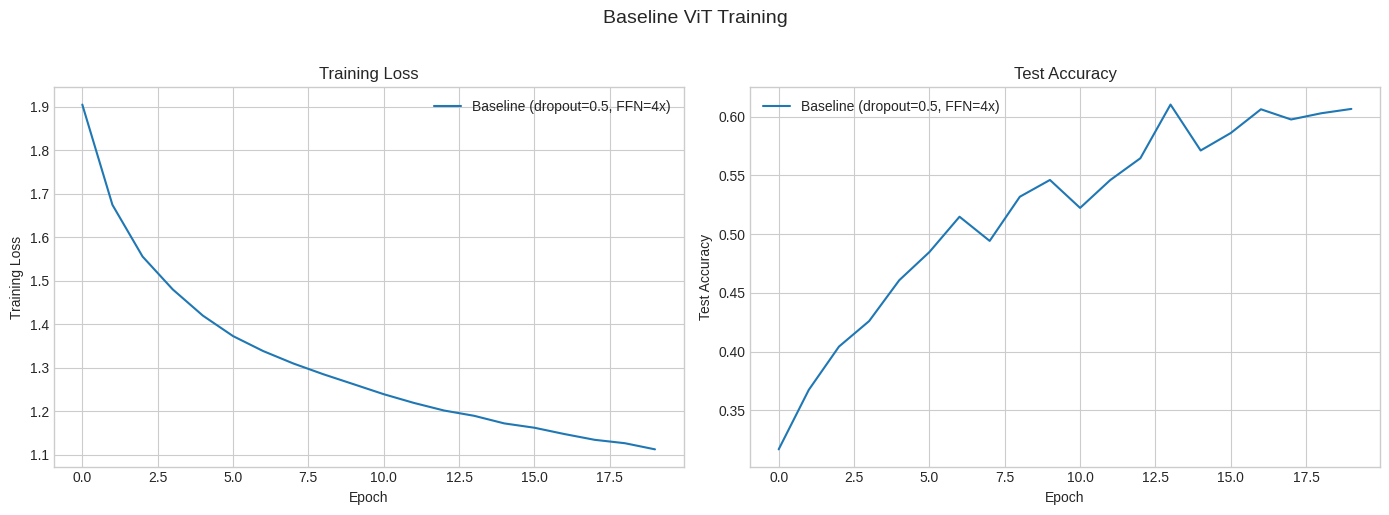

In [9]:
print(f"Baseline best test accuracy: {max(baseline_history['test_acc']):.4f}")
print(f"Baseline parameters: {baseline_history['num_params']:,}")
plot_training_curves([baseline_history], title="Baseline ViT Training")

---
## Section 2: Tier 1 -- Drop-In Changes

Tier 1 tests the simplest prediction: that changing **only hyperparameters** (no architecture change) yields improvement.

Three variants:
- **2a:** Dropout changed from 0.5 to 0.382 (predicted optimal redundancy fraction)
- **2b:** FFN expansion changed from 4x to 2.618x (phi^2, predicted optimal capacity ratio)
- **2c:** Both changes together

All use the **exact same architecture** (BaselineViT). Only the numbers change.

### 2a: Dropout = 0.382

Same architecture, only dropout rate changed from the conventional 0.5 to the theory-predicted 0.382.

In [10]:
torch.manual_seed(SEED)

tier1a_model = BaselineViT(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    ffn_expansion=4.0, dropout=0.382,
)

tier1a_history = train_model(
    tier1a_model, train_loader, test_loader, DEVICE,
    epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
    label="Tier 1a: dropout=0.382",
)

ALL_RESULTS['T1a: dropout=0.382'] = tier1a_history


Training: Tier 1a: dropout=0.382
Parameters: 809,098
  Epoch  1/20 | Loss: 1.8762 | Test Acc: 0.3352 | Time: 21.3s
  Epoch  2/20 | Loss: 1.6192 | Test Acc: 0.3976 | Time: 22.0s
  Epoch  3/20 | Loss: 1.4842 | Test Acc: 0.4371 | Time: 22.6s
  Epoch  4/20 | Loss: 1.4012 | Test Acc: 0.4785 | Time: 22.5s
  Epoch  5/20 | Loss: 1.3365 | Test Acc: 0.5182 | Time: 23.0s
  Epoch  6/20 | Loss: 1.2906 | Test Acc: 0.5370 | Time: 22.8s
  Epoch  7/20 | Loss: 1.2517 | Test Acc: 0.5665 | Time: 22.4s
  Epoch  8/20 | Loss: 1.2173 | Test Acc: 0.5523 | Time: 22.1s
  Epoch  9/20 | Loss: 1.1943 | Test Acc: 0.5610 | Time: 22.4s
  Epoch 10/20 | Loss: 1.1697 | Test Acc: 0.5933 | Time: 22.5s
  Epoch 11/20 | Loss: 1.1432 | Test Acc: 0.5636 | Time: 22.4s
  Epoch 12/20 | Loss: 1.1233 | Test Acc: 0.6177 | Time: 22.2s
  Epoch 13/20 | Loss: 1.1080 | Test Acc: 0.6087 | Time: 22.9s
  Epoch 14/20 | Loss: 1.0912 | Test Acc: 0.6547 | Time: 22.6s
  Epoch 15/20 | Loss: 1.0734 | Test Acc: 0.6191 | Time: 22.6s
  Epoch 16/20 | 

### 2b: FFN Expansion = phi^2 = 2.618x

Same architecture, only FFN expansion changed from 4x to 2.618x. Note this **reduces** parameter count (fewer FFN parameters).

In [11]:
torch.manual_seed(SEED)

tier1b_model = BaselineViT(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    ffn_expansion=PHI_SQ, dropout=0.5,
)

tier1b_history = train_model(
    tier1b_model, train_loader, test_loader, DEVICE,
    epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
    label="Tier 1b: FFN=2.618x",
)

ALL_RESULTS['T1b: FFN=2.618x'] = tier1b_history


Training: Tier 1b: FFN=2.618x
Parameters: 627,142
  Epoch  1/20 | Loss: 1.9031 | Test Acc: 0.2661 | Time: 21.3s
  Epoch  2/20 | Loss: 1.6840 | Test Acc: 0.3922 | Time: 21.7s
  Epoch  3/20 | Loss: 1.5480 | Test Acc: 0.3926 | Time: 23.2s
  Epoch  4/20 | Loss: 1.4679 | Test Acc: 0.4343 | Time: 22.6s
  Epoch  5/20 | Loss: 1.4176 | Test Acc: 0.4930 | Time: 22.3s
  Epoch  6/20 | Loss: 1.3740 | Test Acc: 0.4804 | Time: 21.9s
  Epoch  7/20 | Loss: 1.3423 | Test Acc: 0.5050 | Time: 21.9s
  Epoch  8/20 | Loss: 1.3122 | Test Acc: 0.5325 | Time: 22.1s
  Epoch  9/20 | Loss: 1.2896 | Test Acc: 0.5391 | Time: 21.9s
  Epoch 10/20 | Loss: 1.2705 | Test Acc: 0.5437 | Time: 22.1s
  Epoch 11/20 | Loss: 1.2500 | Test Acc: 0.5449 | Time: 21.7s
  Epoch 12/20 | Loss: 1.2243 | Test Acc: 0.5446 | Time: 21.1s
  Epoch 13/20 | Loss: 1.2156 | Test Acc: 0.5557 | Time: 21.5s
  Epoch 14/20 | Loss: 1.2022 | Test Acc: 0.5744 | Time: 21.5s
  Epoch 15/20 | Loss: 1.1826 | Test Acc: 0.5520 | Time: 22.5s
  Epoch 16/20 | Los

### 2c: Both Changes Together

Dropout=0.382 AND FFN=2.618x. The full Tier 1 configuration.

In [12]:
torch.manual_seed(SEED)

tier1c_model = BaselineViT(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    ffn_expansion=PHI_SQ, dropout=0.382,
)

tier1c_history = train_model(
    tier1c_model, train_loader, test_loader, DEVICE,
    epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
    label="Tier 1c: dropout=0.382 + FFN=2.618x",
)

ALL_RESULTS['T1c: both'] = tier1c_history


Training: Tier 1c: dropout=0.382 + FFN=2.618x
Parameters: 627,142
  Epoch  1/20 | Loss: 1.8807 | Test Acc: 0.2829 | Time: 22.5s
  Epoch  2/20 | Loss: 1.6265 | Test Acc: 0.4275 | Time: 22.6s
  Epoch  3/20 | Loss: 1.4839 | Test Acc: 0.4297 | Time: 22.8s
  Epoch  4/20 | Loss: 1.3944 | Test Acc: 0.4842 | Time: 22.7s
  Epoch  5/20 | Loss: 1.3426 | Test Acc: 0.5271 | Time: 22.5s
  Epoch  6/20 | Loss: 1.2921 | Test Acc: 0.5398 | Time: 22.3s
  Epoch  7/20 | Loss: 1.2561 | Test Acc: 0.5546 | Time: 21.9s
  Epoch  8/20 | Loss: 1.2242 | Test Acc: 0.5828 | Time: 21.0s
  Epoch  9/20 | Loss: 1.1976 | Test Acc: 0.5866 | Time: 21.4s
  Epoch 10/20 | Loss: 1.1754 | Test Acc: 0.5922 | Time: 22.0s
  Epoch 11/20 | Loss: 1.1564 | Test Acc: 0.6059 | Time: 22.0s
  Epoch 12/20 | Loss: 1.1310 | Test Acc: 0.5963 | Time: 22.0s
  Epoch 13/20 | Loss: 1.1218 | Test Acc: 0.5900 | Time: 22.3s
  Epoch 14/20 | Loss: 1.0994 | Test Acc: 0.6217 | Time: 22.5s
  Epoch 15/20 | Loss: 1.0842 | Test Acc: 0.6124 | Time: 22.6s
  E

### 2d: Tier 1 Summary

Compare all Tier 1 variants: accuracy and parameter count.

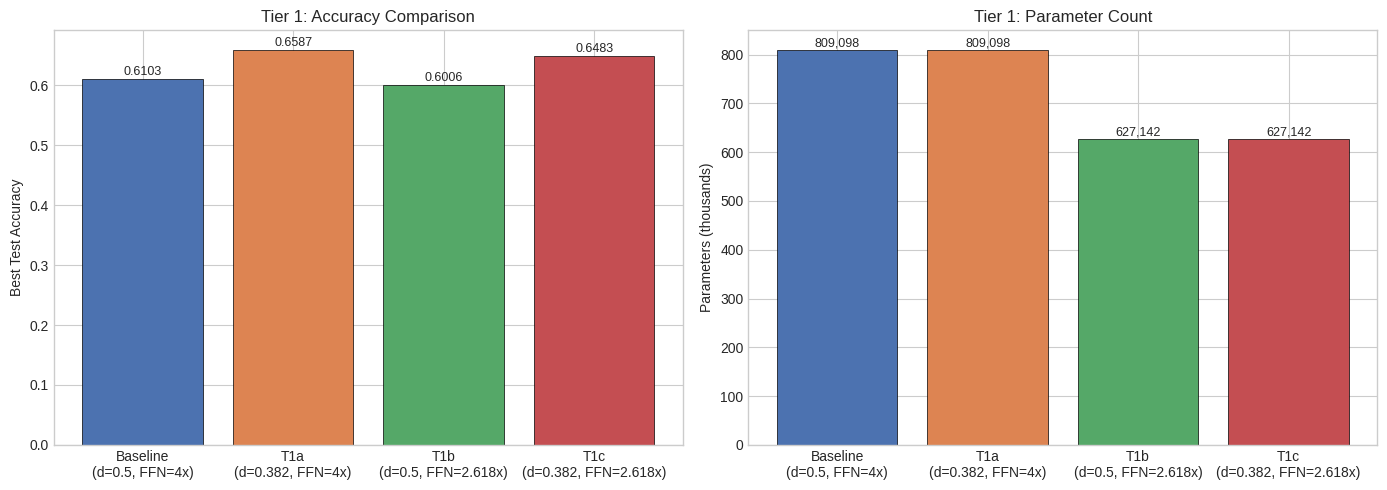


Tier 1 Summary:
Config                                  Params   Best Acc  vs Baseline
----------------------------------------------------------------------
Baseline (d=0.5, FFN=4x)               809,098     0.6103 +     0.0000
T1a (d=0.382, FFN=4x)                  809,098     0.6587 +     0.0484
T1b (d=0.5, FFN=2.618x)                627,142     0.6006     -0.0097
T1c (d=0.382, FFN=2.618x)              627,142     0.6483 +     0.0380


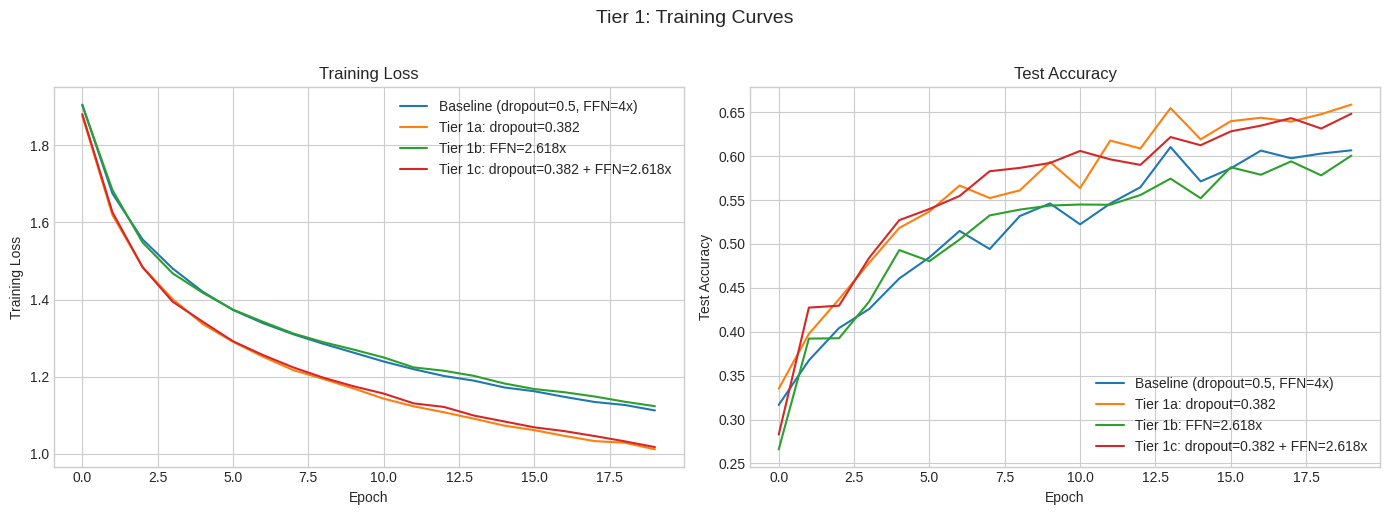

In [13]:
# Collect Tier 1 results
tier1_configs = [
    ('Baseline\n(d=0.5, FFN=4x)', baseline_history),
    ('T1a\n(d=0.382, FFN=4x)', tier1a_history),
    ('T1b\n(d=0.5, FFN=2.618x)', tier1b_history),
    ('T1c\n(d=0.382, FFN=2.618x)', tier1c_history),
]

names = [c[0] for c in tier1_configs]
accs = [max(c[1]['test_acc']) for c in tier1_configs]
params = [c[1]['num_params'] for c in tier1_configs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Accuracy bar chart
bars1 = ax1.bar(names, accs, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Best Test Accuracy')
ax1.set_title('Tier 1: Accuracy Comparison')
for bar, acc in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=9)

# Parameter count bar chart
bars2 = ax2.bar(names, [p/1000 for p in params], color=colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Parameters (thousands)')
ax2.set_title('Tier 1: Parameter Count')
for bar, p in zip(bars2, params):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{p:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print comparison table
print("\nTier 1 Summary:")
print(f"{'Config':<35} {'Params':>10} {'Best Acc':>10} {'vs Baseline':>12}")
print("-" * 70)
baseline_acc = max(baseline_history['test_acc'])
for name_raw, h in tier1_configs:
    name = name_raw.replace('\n', ' ')
    best = max(h['test_acc'])
    delta = best - baseline_acc
    sign = '+' if delta >= 0 else ''
    print(f"{name:<35} {h['num_params']:>10,} {best:>10.4f} {sign}{delta:>11.4f}")

# Plot training curves
plot_training_curves(
    [baseline_history, tier1a_history, tier1b_history, tier1c_history],
    title="Tier 1: Training Curves"
)

---
## Section 3: Tier 2 -- Observer Attention

Tier 2 adds **inter-head message passing** on a hypercube graph. The idea: arrange the 8 attention heads on the vertices of a 3D cube. After computing attention, each head mixes a fraction alpha=0.382 of its output with its 3 neighbors.

This is implemented efficiently as a single matrix multiply using a precomputed diffusion matrix M = ((1-alpha)*I + alpha/degree * A)^R.

### 3a: Hypercube Topology

Build the adjacency matrix for a hypercube graph and the diffusion matrix for R rounds of message passing.

In [14]:
def hypercube_adjacency(num_heads: int) -> torch.Tensor:
    """Generate adjacency matrix for hypercube graph on num_heads nodes.

    For N = 2^d heads, head i connects to heads obtained by flipping
    each bit of i's binary representation.

    Args:
        num_heads: Must be a power of 2.

    Returns:
        adj: BoolTensor of shape (num_heads, num_heads).
    """
    assert num_heads > 0 and (num_heads & (num_heads - 1)) == 0, \
        f"num_heads must be a power of 2, got {num_heads}"
    d = int(round(math.log2(num_heads)))
    adj = torch.zeros(num_heads, num_heads, dtype=torch.bool)
    for i in range(num_heads):
        for bit in range(d):
            j = i ^ (1 << bit)  # flip bit
            adj[i, j] = True
    return adj


def build_diffusion_matrix(
    num_heads: int,
    alpha: float = 0.382,
    rounds: int = 3,
) -> torch.Tensor:
    """Build the R-round diffusion matrix for hypercube message passing.

    M_1 = (1 - alpha) * I + (alpha / degree) * A
    M_R = M_1 ^ R  (matrix power)

    Args:
        num_heads: Power of 2.
        alpha: Mixing coefficient. Default 0.382.
        rounds: Number of message passing rounds. Default 3.

    Returns:
        M: FloatTensor of shape (num_heads, num_heads).
    """
    adj = hypercube_adjacency(num_heads).float()
    d = int(round(math.log2(num_heads)))  # degree = d for hypercube
    M = (1 - alpha) * torch.eye(num_heads) + (alpha / d) * adj
    M_R = torch.linalg.matrix_power(M, rounds)
    return M_R


# Test it
adj_8 = hypercube_adjacency(8)
M_8 = build_diffusion_matrix(8, alpha=0.382, rounds=3)
print("Adjacency matrix for 8 heads (3D cube):")
print(adj_8.int())
print(f"\nDiffusion matrix M (alpha=0.382, R=3):")
print(M_8.numpy().round(4))
print(f"\nRow sums (should be 1.0): {M_8.sum(dim=1).numpy().round(6)}")

Adjacency matrix for 8 heads (3D cube):
tensor([[0, 1, 1, 0, 1, 0, 0, 0],
        [1, 0, 0, 1, 0, 1, 0, 0],
        [1, 0, 0, 1, 0, 0, 1, 0],
        [0, 1, 1, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 1, 1, 0],
        [0, 1, 0, 0, 1, 0, 0, 1],
        [0, 0, 1, 0, 1, 0, 0, 1],
        [0, 0, 0, 1, 0, 1, 1, 0]], dtype=torch.int32)

Diffusion matrix M (alpha=0.382, R=3):
[[0.3262 0.1603 0.1603 0.0601 0.1603 0.0601 0.0601 0.0124]
 [0.1603 0.3262 0.0601 0.1603 0.0601 0.1603 0.0124 0.0601]
 [0.1603 0.0601 0.3262 0.1603 0.0601 0.0124 0.1603 0.0601]
 [0.0601 0.1603 0.1603 0.3262 0.0124 0.0601 0.0601 0.1603]
 [0.1603 0.0601 0.0601 0.0124 0.3262 0.1603 0.1603 0.0601]
 [0.0601 0.1603 0.0124 0.0601 0.1603 0.3262 0.0601 0.1603]
 [0.0601 0.0124 0.1603 0.0601 0.1603 0.0601 0.3262 0.1603]
 [0.0124 0.0601 0.0601 0.1603 0.0601 0.1603 0.1603 0.3262]]

Row sums (should be 1.0): [1. 1. 1. 1. 1. 1. 1. 1.]


### Visualize the Hypercube Topology

A small visualization of the 3D cube graph connecting 8 attention heads.

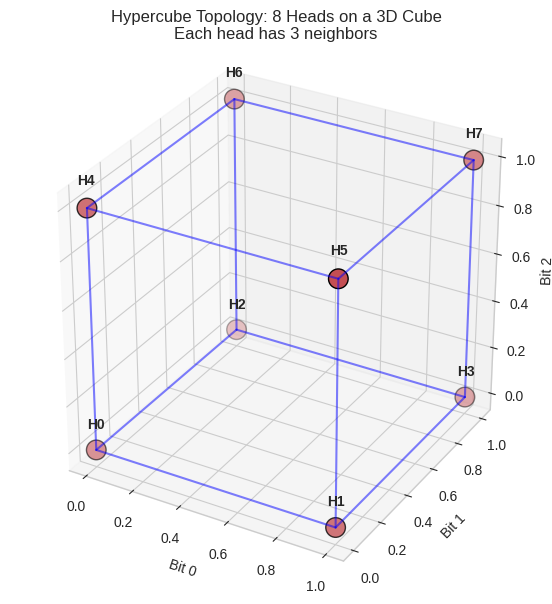

In [15]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Cube vertices in 3D
coords = np.array([
    [0, 0, 0],  # 0 = 000
    [1, 0, 0],  # 1 = 001
    [0, 1, 0],  # 2 = 010
    [1, 1, 0],  # 3 = 011
    [0, 0, 1],  # 4 = 100
    [1, 0, 1],  # 5 = 101
    [0, 1, 1],  # 6 = 110
    [1, 1, 1],  # 7 = 111
])

# Draw edges
adj = hypercube_adjacency(8)
for i in range(8):
    for j in range(i+1, 8):
        if adj[i, j]:
            ax.plot3D(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                [coords[i, 2], coords[j, 2]],
                'b-', alpha=0.5, linewidth=1.5
            )

# Draw vertices
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
           s=200, c='#C44E52', edgecolors='black', zorder=5)

# Label vertices
for i in range(8):
    ax.text(coords[i, 0], coords[i, 1], coords[i, 2] + 0.08,
            f'H{i}', fontsize=10, ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Bit 0')
ax.set_ylabel('Bit 1')
ax.set_zlabel('Bit 2')
ax.set_title('Hypercube Topology: 8 Heads on a 3D Cube\nEach head has 3 neighbors', fontsize=12)
ax.set_box_aspect([1, 1, 1])
plt.tight_layout()
plt.show()

### 3b: Observer Attention Module

Multi-head attention with hypercube inter-head message passing. Drop-in replacement for StandardAttention. The only addition: after computing per-head attention outputs, heads exchange information via the precomputed diffusion matrix.

In [16]:
class ObserverAttention(nn.Module):
    """Multi-head attention with hypercube inter-head message passing.

    Drop-in replacement for StandardAttention.
    Cost: one extra (num_heads, num_heads) matmul per forward pass.
    Parameters added: 0 (alpha is fixed).
    """

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        alpha: float = 0.382,
        rounds: int = 3,
        dropout: float = 0.382,
    ):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.scale = self.d_head ** -0.5

        # Standard QKV + output projections
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

        # Precompute diffusion matrix (registered as buffer, not parameter)
        diffusion = build_diffusion_matrix(num_heads, alpha, rounds)
        self.register_buffer('diffusion_matrix', diffusion)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x: (B, T, D). Returns: (B, T, D)."""
        B, T, D = x.shape
        H = self.num_heads
        d_h = self.d_head

        # QKV: (B, T, 3*D) -> 3 x (B, H, T, d_h)
        qkv = self.qkv(x).reshape(B, T, 3, H, d_h).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each: (B, H, T, d_h)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, H, T, T)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        head_out = attn @ v  # (B, H, T, d_h)

        # === OBSERVER: inter-head message passing ===
        head_out = head_out.permute(0, 2, 1, 3)  # (B, T, H, d_h)
        M = self.diffusion_matrix  # (H, H)
        head_out = torch.einsum('bthd,gh->btgd', head_out, M)  # (B, T, H, d_h)

        # Reassemble
        out = head_out.reshape(B, T, D)  # (B, T, D)
        out = self.out_proj(out)
        out = self.proj_drop(out)
        return out

print("ObserverAttention defined.")

ObserverAttention defined.


### Observer Block (Tier 2)

Transformer block using ObserverAttention instead of StandardAttention, plus Tier 1 changes (dropout=0.382, FFN=2.618x).

In [17]:
class ObserverBlock_T2(nn.Module):
    """Tier 2 Observer block: Observer attention + phi-optimal FFN."""

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        alpha: float = 0.382,
        rounds: int = 3,
        dropout: float = 0.382,
        ffn_expansion: float = 2.618,
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = ObserverAttention(
            d_model, num_heads, alpha=alpha, rounds=rounds, dropout=dropout
        )
        self.norm2 = nn.LayerNorm(d_model)
        ffn_dim = round(d_model * ffn_expansion)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x: (B, T, D). Returns: (B, T, D)."""
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

print("ObserverBlock_T2 defined.")

ObserverBlock_T2 defined.


### 3c: Observer ViT (Tier 2)

Build a ViT model using ObserverAttention (inter-head message passing) + Tier 1 changes. Same patch embedding and classification head as the baseline.

In [18]:
class ObserverViT_T2(nn.Module):
    """ViT with Tier 2 Observer Attention + Tier 1 hyperparameters."""

    def __init__(
        self,
        img_size: int = 32,
        patch_size: int = 4,
        in_channels: int = 3,
        num_classes: int = 10,
        d_model: int = 128,
        num_heads: int = 8,
        num_layers: int = 4,
        alpha: float = 0.382,
        rounds: int = 3,
        dropout: float = 0.382,
        ffn_expansion: float = 2.618,
    ):
        super().__init__()
        self.d_model = d_model
        num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(in_channels, d_model,
                                     kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, d_model) * 0.02)
        self.embed_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            ObserverBlock_T2(d_model, num_heads, alpha, rounds, dropout, ffn_expansion)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x: (B, C, H, W). Returns: (B, num_classes)."""
        x = self.patch_embed(x)           # (B, D, H', W')
        x = x.flatten(2).transpose(1, 2)  # (B, T, D)
        x = x + self.pos_embed
        x = self.embed_drop(x)

        for block in self.blocks:
            x = block(x)

        x = x.mean(dim=1)
        x = self.norm(x)
        return self.head(x)

print("ObserverViT_T2 defined.")

ObserverViT_T2 defined.


### Train Tier 2 Observer ViT

In [19]:
torch.manual_seed(SEED)

tier2_model = ObserverViT_T2(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    alpha=0.382, rounds=3, dropout=0.382, ffn_expansion=PHI_SQ,
)

tier2_history = train_model(
    tier2_model, train_loader, test_loader, DEVICE,
    epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
    label="Tier 2: Observer Attention (alpha=0.382)",
)

ALL_RESULTS['T2: Observer Attn'] = tier2_history


Training: Tier 2: Observer Attention (alpha=0.382)
Parameters: 627,142
  Epoch  1/20 | Loss: 1.8815 | Test Acc: 0.2960 | Time: 22.5s
  Epoch  2/20 | Loss: 1.6446 | Test Acc: 0.4135 | Time: 22.3s
  Epoch  3/20 | Loss: 1.5079 | Test Acc: 0.4096 | Time: 22.3s
  Epoch  4/20 | Loss: 1.4169 | Test Acc: 0.4746 | Time: 22.5s
  Epoch  5/20 | Loss: 1.3586 | Test Acc: 0.5238 | Time: 22.6s
  Epoch  6/20 | Loss: 1.3140 | Test Acc: 0.5181 | Time: 22.2s
  Epoch  7/20 | Loss: 1.2750 | Test Acc: 0.5461 | Time: 22.4s
  Epoch  8/20 | Loss: 1.2400 | Test Acc: 0.5772 | Time: 21.9s
  Epoch  9/20 | Loss: 1.2133 | Test Acc: 0.5853 | Time: 21.7s
  Epoch 10/20 | Loss: 1.1900 | Test Acc: 0.5719 | Time: 21.5s
  Epoch 11/20 | Loss: 1.1700 | Test Acc: 0.5985 | Time: 21.7s
  Epoch 12/20 | Loss: 1.1449 | Test Acc: 0.5944 | Time: 21.6s
  Epoch 13/20 | Loss: 1.1342 | Test Acc: 0.6030 | Time: 21.7s
  Epoch 14/20 | Loss: 1.1122 | Test Acc: 0.6185 | Time: 21.8s
  Epoch 15/20 | Loss: 1.0945 | Test Acc: 0.6136 | Time: 22.3

### 3d: Alpha Sweep

Sweep the mixing rate alpha from 0.1 to 0.7 to test whether the predicted optimal value of 0.382 is near the peak. Each configuration is trained for a short run to map the landscape.

In [20]:
alpha_values = [0.1, 0.2, 0.3, 0.382, 0.4, 0.5, 0.6, 0.7]
alpha_results = []

for alpha_val in alpha_values:
    torch.manual_seed(SEED)
    model_a = ObserverViT_T2(
        img_size=IMG_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
        d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
        alpha=alpha_val, rounds=3, dropout=0.382, ffn_expansion=PHI_SQ,
    )
    h = train_model(
        model_a, train_loader, test_loader, DEVICE,
        epochs=ALPHA_SWEEP_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
        label=f"Alpha sweep: alpha={alpha_val}",
    )
    alpha_results.append({
        'alpha': alpha_val,
        'best_acc': max(h['test_acc']),
        'final_acc': h['test_acc'][-1],
    })

print("\nAlpha sweep complete.")


Training: Alpha sweep: alpha=0.1
Parameters: 627,142
  Epoch  1/8 | Loss: 1.8814 | Test Acc: 0.2791 | Time: 22.1s
  Epoch  2/8 | Loss: 1.6312 | Test Acc: 0.4219 | Time: 21.7s
  Epoch  3/8 | Loss: 1.4930 | Test Acc: 0.4151 | Time: 22.2s
  Epoch  4/8 | Loss: 1.4080 | Test Acc: 0.4742 | Time: 22.1s
  Epoch  5/8 | Loss: 1.3522 | Test Acc: 0.5278 | Time: 21.8s
  Epoch  6/8 | Loss: 1.3017 | Test Acc: 0.5270 | Time: 22.6s
  Epoch  7/8 | Loss: 1.2631 | Test Acc: 0.5519 | Time: 22.3s
  Epoch  8/8 | Loss: 1.2267 | Test Acc: 0.5790 | Time: 22.1s

  Best test accuracy: 0.5790
  Total training time: 176.9s

Training: Alpha sweep: alpha=0.2
Parameters: 627,142
  Epoch  1/8 | Loss: 1.8806 | Test Acc: 0.2879 | Time: 22.5s
  Epoch  2/8 | Loss: 1.6284 | Test Acc: 0.4253 | Time: 22.7s
  Epoch  3/8 | Loss: 1.4964 | Test Acc: 0.4100 | Time: 22.1s
  Epoch  4/8 | Loss: 1.4087 | Test Acc: 0.4773 | Time: 22.0s
  Epoch  5/8 | Loss: 1.3526 | Test Acc: 0.5244 | Time: 22.2s
  Epoch  6/8 | Loss: 1.3050 | Test Acc:

### Alpha Sweep Results

Plot accuracy vs alpha. The theory predicts a peak near alpha=0.382 (marked with a red dashed line).

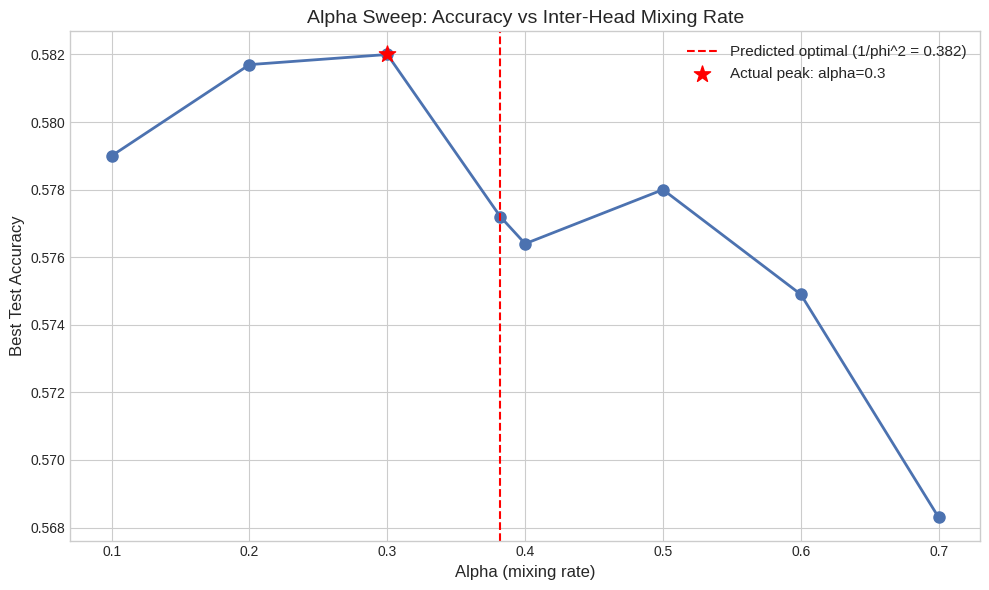

   Alpha   Best Acc
--------------------
   0.100     0.5790
   0.200     0.5817
   0.300     0.5820
   0.382     0.5772  <-- predicted
   0.400     0.5764
   0.500     0.5780
   0.600     0.5749
   0.700     0.5683


In [21]:
alphas = [r['alpha'] for r in alpha_results]
best_accs = [r['best_acc'] for r in alpha_results]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(alphas, best_accs, 'o-', color='#4C72B0', markersize=8, linewidth=2)
ax.axvline(x=0.382, color='red', linestyle='--', linewidth=1.5,
           label=f'Predicted optimal (1/phi^2 = 0.382)')

# Mark the actual peak
peak_idx = np.argmax(best_accs)
ax.scatter([alphas[peak_idx]], [best_accs[peak_idx]], color='red', s=150,
           zorder=5, marker='*', label=f'Actual peak: alpha={alphas[peak_idx]}')

ax.set_xlabel('Alpha (mixing rate)', fontsize=12)
ax.set_ylabel('Best Test Accuracy', fontsize=12)
ax.set_title('Alpha Sweep: Accuracy vs Inter-Head Mixing Rate', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print table
print(f"{'Alpha':>8} {'Best Acc':>10}")
print("-" * 20)
for r in alpha_results:
    marker = '  <-- predicted' if r['alpha'] == 0.382 else ''
    print(f"{r['alpha']:>8.3f} {r['best_acc']:>10.4f}{marker}")

### 3e: Tier 2 Summary

Compare baseline, best Tier 1, and Tier 2 results.

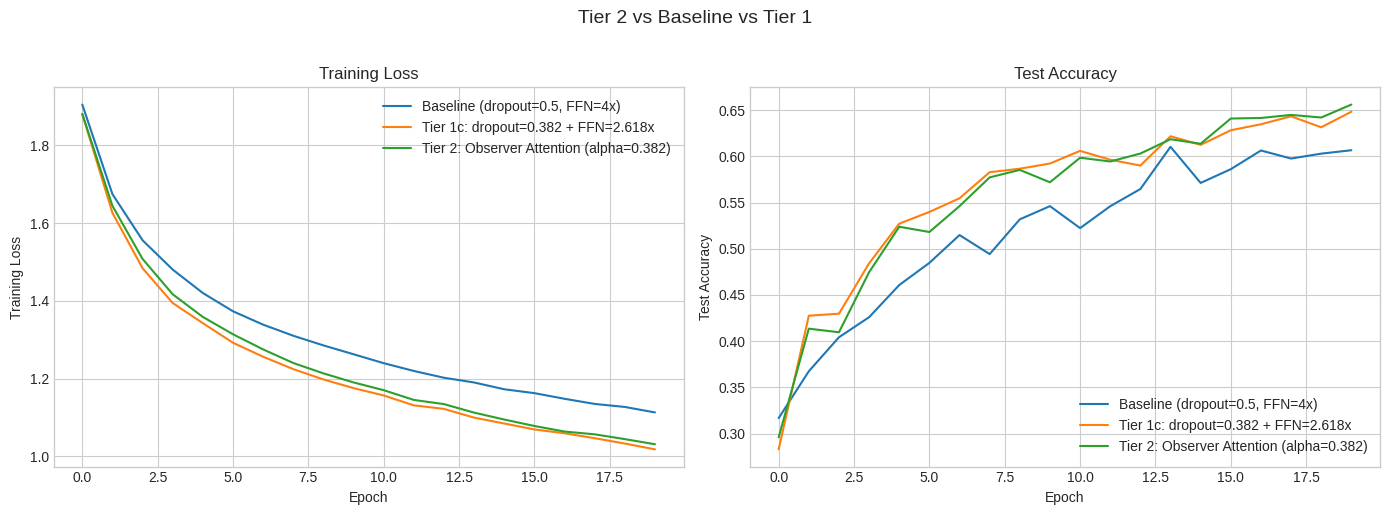

Config                             Params   Best Acc  vs Baseline
-----------------------------------------------------------------
Baseline                          809,098     0.6103 +     0.0000
T1c: phi-optimal                  627,142     0.6483 +     0.0380
T2: Observer Attn                 627,142     0.6560 +     0.0457


In [22]:
tier2_configs = [
    ('Baseline', baseline_history),
    ('T1c: phi-optimal', tier1c_history),
    ('T2: Observer Attn', tier2_history),
]

plot_training_curves(
    [h for _, h in tier2_configs],
    title="Tier 2 vs Baseline vs Tier 1"
)

print(f"{'Config':<30} {'Params':>10} {'Best Acc':>10} {'vs Baseline':>12}")
print("-" * 65)
for name, h in tier2_configs:
    best = max(h['test_acc'])
    delta = best - baseline_acc
    sign = '+' if delta >= 0 else ''
    print(f"{name:<30} {h['num_params']:>10,} {best:>10.4f} {sign}{delta:>11.4f}")

---
## Section 4: Tier 3 -- Full Observer Transformer

The full Observer Transformer combines all innovations:
1. **Tier 1:** dropout=0.382, FFN expansion=2.618x
2. **Tier 2:** hypercube inter-head message passing
3. **Tier 3 (new):** Dual-channel MVSU attention with inhibitory cross-correction

Each attention head computes attention through TWO channels:
- **Primary:** full-rank Q/K/V (standard)
- **Secondary:** low-rank Q/K (different initialization), sharing V with primary
- **Cross-correction:** output = primary + w_cross * secondary, where w_cross is per-head, initialized at -0.1

The negative w_cross performs echo cancellation: the secondary channel (which has different errors due to low-rank projection) subtracts its estimate of the self-referential contamination.

### 4a: Dual Channel Observer Attention

The core Tier 3 module: primary full-rank attention + low-rank secondary attention + per-head inhibitory cross-weight + hypercube mixing.

In [23]:
class DualChannelObserverAttention(nn.Module):
    """Multi-head attention with:
    1. Inhibitory dual-channel (MVSU) within each head
    2. Hypercube inter-head message passing

    The primary channel is standard full-rank attention.
    The secondary channel is low-rank attention with different initialization.
    Cross-correction: out = primary + w_cross * secondary (w_cross < 0).
    """

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        secondary_rank: int = 64,
        w_cross_init: float = -0.1,
        alpha: float = 0.382,
        rounds: int = 3,
        dropout: float = 0.382,
    ):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.scale = self.d_head ** -0.5
        self.secondary_rank = secondary_rank

        # Primary channel: full-rank QKV
        self.qkv_primary = nn.Linear(d_model, 3 * d_model)

        # Secondary channel: low-rank QK, shared V with primary
        self.q_sec_down = nn.Linear(d_model, secondary_rank, bias=False)
        self.q_sec_up = nn.Linear(secondary_rank, d_model, bias=False)
        self.k_sec_down = nn.Linear(d_model, secondary_rank, bias=False)
        self.k_sec_up = nn.Linear(secondary_rank, d_model, bias=False)

        # Initialize secondary with DIFFERENT distribution than primary
        nn.init.orthogonal_(self.q_sec_down.weight)
        nn.init.orthogonal_(self.q_sec_up.weight)
        nn.init.orthogonal_(self.k_sec_down.weight)
        nn.init.orthogonal_(self.k_sec_up.weight)

        # Output projection (shared)
        self.out_proj = nn.Linear(d_model, d_model)

        # Per-head cross-correction weight, initialized negative
        self.w_cross = nn.Parameter(
            torch.full((num_heads,), w_cross_init)
        )

        # Dropout
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

        # Hypercube message passing
        diffusion = build_diffusion_matrix(num_heads, alpha, rounds)
        self.register_buffer('diffusion_matrix', diffusion)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x: (B, T, D). Returns: (B, T, D)."""
        B, T, D = x.shape
        H = self.num_heads
        d_h = self.d_head

        # --- Primary channel: standard attention ---
        qkv = self.qkv_primary(x).reshape(B, T, 3, H, d_h).permute(2, 0, 3, 1, 4)
        q_p, k_p, v = qkv[0], qkv[1], qkv[2]  # (B, H, T, d_h)

        attn_p = (q_p @ k_p.transpose(-2, -1)) * self.scale  # (B, H, T, T)
        attn_p = attn_p.softmax(dim=-1)
        attn_p = self.attn_drop(attn_p)
        primary_out = attn_p @ v  # (B, H, T, d_h)

        # --- Secondary channel: low-rank attention, shared V ---
        q_s = self.q_sec_up(self.q_sec_down(x))  # (B, T, D)
        k_s = self.k_sec_up(self.k_sec_down(x))  # (B, T, D)
        q_s = q_s.reshape(B, T, H, d_h).permute(0, 2, 1, 3)  # (B, H, T, d_h)
        k_s = k_s.reshape(B, T, H, d_h).permute(0, 2, 1, 3)  # (B, H, T, d_h)

        attn_s = (q_s @ k_s.transpose(-2, -1)) * self.scale  # (B, H, T, T)
        attn_s = attn_s.softmax(dim=-1)
        attn_s = self.attn_drop(attn_s)
        secondary_out = attn_s @ v  # (B, H, T, d_h)

        # --- Cross-correction: primary + w_cross * secondary ---
        w = self.w_cross.view(1, H, 1, 1)  # (1, H, 1, 1)
        head_out = primary_out + w * secondary_out  # (B, H, T, d_h)

        # --- Inter-head message passing ---
        head_out = head_out.permute(0, 2, 1, 3)  # (B, T, H, d_h)
        head_out = torch.einsum('bthd,gh->btgd', head_out, self.diffusion_matrix)
        out = head_out.reshape(B, T, D)  # (B, T, D)

        out = self.out_proj(out)
        out = self.proj_drop(out)
        return out

print("DualChannelObserverAttention defined.")

DualChannelObserverAttention defined.


### 4b: Observer Block (Tier 3)

Full Observer block: dual-channel attention + phi-optimal FFN + pre-norm + residuals.

In [24]:
class ObserverBlock(nn.Module):
    """Full Observer Transformer block.

    Components:
    - Pre-norm dual-channel observer attention (with MVSU)
    - Pre-norm FFN with phi^2 expansion
    - Residual connections
    - Dropout at 0.382
    """

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        secondary_rank: int = 64,
        w_cross_init: float = -0.1,
        alpha: float = 0.382,
        rounds: int = 3,
        dropout: float = 0.382,
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = DualChannelObserverAttention(
            d_model=d_model,
            num_heads=num_heads,
            secondary_rank=secondary_rank,
            w_cross_init=w_cross_init,
            alpha=alpha,
            rounds=rounds,
            dropout=dropout,
        )
        self.norm2 = nn.LayerNorm(d_model)
        ffn_dim = round(d_model * PHI_SQ)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x: (B, T, D). Returns: (B, T, D)."""
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

print("ObserverBlock defined.")

ObserverBlock defined.


### 4c: Full Observer Transformer

The complete Observer Transformer: patch embedding, stacked Observer blocks, classification head.

In [25]:
class ObserverTransformer(nn.Module):
    """Complete Observer Transformer for image classification.

    Combines:
    - Patch embedding with positional encoding
    - N stacked Observer Blocks (dual-channel attention + phi-FFN)
    - Mean-pool classification head
    """

    def __init__(
        self,
        img_size: int = 32,
        patch_size: int = 4,
        in_channels: int = 3,
        num_classes: int = 10,
        d_model: int = 128,
        num_heads: int = 8,
        num_layers: int = 4,
        secondary_rank: int = 16,
        w_cross_init: float = -0.1,
        alpha: float = 0.382,
        rounds: int = 3,
        dropout: float = 0.382,
    ):
        super().__init__()
        self.d_model = d_model
        num_patches = (img_size // patch_size) ** 2

        # Patch embedding
        self.patch_embed = nn.Conv2d(
            in_channels, d_model,
            kernel_size=patch_size, stride=patch_size
        )
        self.pos_embed = nn.Parameter(
            torch.randn(1, num_patches, d_model) * 0.02
        )
        self.embed_drop = nn.Dropout(dropout)

        # Observer blocks
        self.blocks = nn.ModuleList([
            ObserverBlock(
                d_model=d_model,
                num_heads=num_heads,
                secondary_rank=secondary_rank,
                w_cross_init=w_cross_init,
                alpha=alpha,
                rounds=rounds,
                dropout=dropout,
            )
            for _ in range(num_layers)
        ])

        # Classification head
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        self._init_weights()

    def _init_weights(self):
        """Initialize weights. w_cross is already initialized in attention module."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
        # Re-initialize w_cross after _init_weights has run
        for module in self.modules():
            if hasattr(module, 'w_cross'):
                nn.init.constant_(module.w_cross, -0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x: (B, C, H, W). Returns: (B, num_classes)."""
        # Patch embed
        x = self.patch_embed(x)           # (B, D, H', W')
        x = x.flatten(2).transpose(1, 2)  # (B, T, D)

        # Add positional embedding
        x = x + self.pos_embed  # (B, T, D)
        x = self.embed_drop(x)

        # Transformer blocks
        for block in self.blocks:
            x = block(x)  # (B, T, D)

        # Classification: mean pool -> norm -> head
        x = x.mean(dim=1)       # (B, D)
        x = self.norm(x)        # (B, D)
        return self.head(x)     # (B, num_classes)


# Configuration factory functions
def observer_transformer_tiny(**kwargs):
    defaults = dict(d_model=128, num_heads=8, num_layers=4,
                    secondary_rank=16, patch_size=4)
    defaults.update(kwargs)
    return ObserverTransformer(**defaults)

def observer_transformer_small(**kwargs):
    defaults = dict(d_model=256, num_heads=8, num_layers=6,
                    secondary_rank=32, patch_size=4)
    defaults.update(kwargs)
    return ObserverTransformer(**defaults)

print("ObserverTransformer and config factories defined.")

ObserverTransformer and config factories defined.


### Verify the Model Runs

Quick sanity check: pass a dummy batch through the model, verify output shape, check w_cross initialization.

In [26]:
# Quick verification
test_model = ObserverTransformer(
    img_size=32, patch_size=4, in_channels=3, num_classes=10,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    secondary_rank=SECONDARY_RANK, dropout=0.382,
)

dummy_input = torch.randn(2, 3, 32, 32)  # 2 fake CIFAR images
logits = test_model(dummy_input)
assert logits.shape == (2, 10), f"Expected (2, 10), got {logits.shape}"
print(f"Output shape: {logits.shape} -- correct")

# Check w_cross values
print("\nw_cross values (should be around -0.1):")
for name, param in test_model.named_parameters():
    if 'w_cross' in name:
        print(f"  {name}: {param.data.numpy()}")

# Count parameters
total_params = count_parameters(test_model)
print(f"\nTotal parameters: {total_params:,}")
print("Model verification passed.")
del test_model, dummy_input, logits

Output shape: torch.Size([2, 10]) -- correct

w_cross values (should be around -0.1):
  blocks.0.attn.w_cross: [-0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1]
  blocks.1.attn.w_cross: [-0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1]
  blocks.2.attn.w_cross: [-0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1]
  blocks.3.attn.w_cross: [-0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1]

Total parameters: 659,942
Model verification passed.


### 4d: Train the Full Observer Transformer

Train OT-Tiny on CIFAR-10, recording w_cross evolution across epochs.

In [27]:
torch.manual_seed(SEED)

ot_model = ObserverTransformer(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    secondary_rank=SECONDARY_RANK, w_cross_init=-0.1,
    alpha=0.382, rounds=3, dropout=0.382,
)

ot_history = train_model(
    ot_model, train_loader, test_loader, DEVICE,
    epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
    label="Tier 3: Full Observer Transformer",
    w_cross_no_decay=True,
)

ALL_RESULTS['T3: Full OT'] = ot_history


Training: Tier 3: Full Observer Transformer
Parameters: 659,942
  Epoch  1/20 | Loss: 1.8842 | Test Acc: 0.3271 | Time: 24.8s
  Epoch  2/20 | Loss: 1.6393 | Test Acc: 0.3958 | Time: 24.9s
  Epoch  3/20 | Loss: 1.5032 | Test Acc: 0.4441 | Time: 24.9s
  Epoch  4/20 | Loss: 1.4146 | Test Acc: 0.5115 | Time: 24.9s
  Epoch  5/20 | Loss: 1.3539 | Test Acc: 0.5152 | Time: 24.5s
  Epoch  6/20 | Loss: 1.3017 | Test Acc: 0.5546 | Time: 24.6s
  Epoch  7/20 | Loss: 1.2643 | Test Acc: 0.5280 | Time: 24.5s
  Epoch  8/20 | Loss: 1.2256 | Test Acc: 0.5505 | Time: 24.8s
  Epoch  9/20 | Loss: 1.1996 | Test Acc: 0.5879 | Time: 24.6s
  Epoch 10/20 | Loss: 1.1669 | Test Acc: 0.5668 | Time: 25.0s
  Epoch 11/20 | Loss: 1.1484 | Test Acc: 0.6096 | Time: 24.9s
  Epoch 12/20 | Loss: 1.1292 | Test Acc: 0.5884 | Time: 25.3s
  Epoch 13/20 | Loss: 1.1046 | Test Acc: 0.6174 | Time: 25.2s
  Epoch 14/20 | Loss: 1.0888 | Test Acc: 0.6130 | Time: 25.1s
  Epoch 15/20 | Loss: 1.0772 | Test Acc: 0.6260 | Time: 25.6s
  Epo

### Training Curves

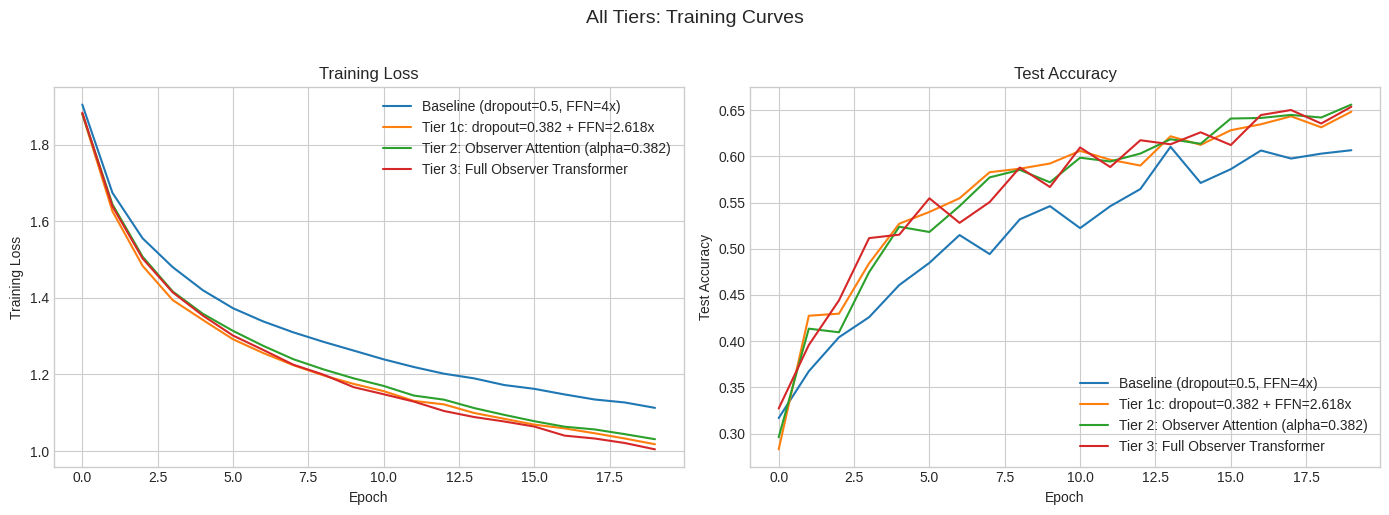

In [28]:
plot_training_curves(
    [baseline_history, tier1c_history, tier2_history, ot_history],
    title="All Tiers: Training Curves"
)

### 4e: w_cross Analysis

Examine the learned w_cross values across heads and training epochs. The key question: **does w_cross stay negative?** Negative values confirm the inhibitory cross-correction mechanism is active.

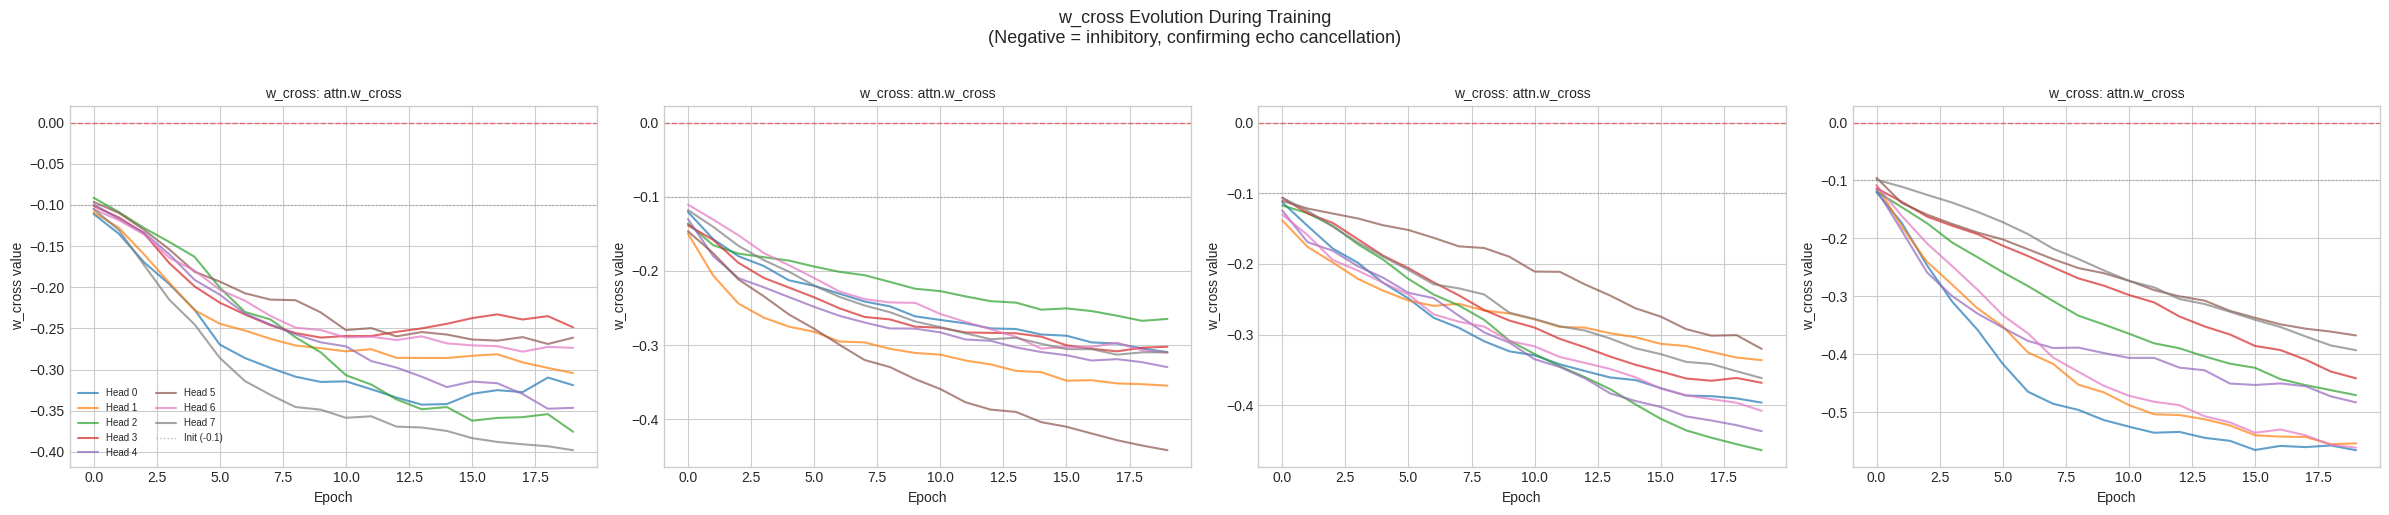


Final w_cross values (last epoch):
  blocks.0.attn.w_cross:
    Values: [-0.319  -0.3043 -0.3756 -0.2487 -0.3465 -0.2613 -0.2737 -0.3979]
    Mean: -0.3159, Range: [-0.3979, -0.2487]
    Negative: 8/8 heads
  blocks.1.attn.w_cross:
    Values: [-0.3096 -0.3547 -0.2647 -0.3023 -0.3297 -0.4417 -0.3104 -0.3095]
    Mean: -0.3278, Range: [-0.4417, -0.2647]
    Negative: 8/8 heads
  blocks.2.attn.w_cross:
    Values: [-0.3962 -0.3361 -0.4635 -0.3682 -0.4366 -0.3202 -0.4078 -0.3615]
    Mean: -0.3863, Range: [-0.4635, -0.3202]
    Negative: 8/8 heads
  blocks.3.attn.w_cross:
    Values: [-0.5651 -0.5534 -0.4702 -0.4412 -0.4827 -0.3672 -0.5606 -0.3927]
    Mean: -0.4791, Range: [-0.5651, -0.3672]
    Negative: 8/8 heads


In [29]:
if ot_history['w_cross_history']:
    # Collect w_cross values across epochs
    # Each entry is a dict {param_name: array_of_per_head_values}
    epochs_data = ot_history['w_cross_history']

    # Get all unique layer names
    layer_names = sorted(epochs_data[0].keys())

    fig, axes = plt.subplots(1, len(layer_names), figsize=(6*len(layer_names), 5),
                             squeeze=False)
    axes = axes[0]

    for idx, layer_name in enumerate(layer_names):
        ax = axes[idx]
        # shape: (num_epochs, num_heads)
        w_cross_over_time = np.array([ep[layer_name] for ep in epochs_data])
        n_heads = w_cross_over_time.shape[1]

        for h in range(n_heads):
            ax.plot(w_cross_over_time[:, h], label=f'Head {h}', alpha=0.7)

        ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
        ax.axhline(y=-0.1, color='gray', linestyle=':', linewidth=1, alpha=0.5,
                   label='Init (-0.1)')
        short_name = layer_name.split('.')[-2] + '.' + layer_name.split('.')[-1]
        ax.set_title(f'w_cross: {short_name}', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('w_cross value')
        if idx == 0:
            ax.legend(fontsize=7, ncol=2)

    plt.suptitle('w_cross Evolution During Training\n(Negative = inhibitory, confirming echo cancellation)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary statistics
    final_w_cross = epochs_data[-1]
    print("\nFinal w_cross values (last epoch):")
    for name in layer_names:
        vals = final_w_cross[name]
        n_negative = np.sum(vals < 0)
        print(f"  {name}:")
        print(f"    Values: {np.array2string(vals, precision=4)}")
        print(f"    Mean: {vals.mean():.4f}, Range: [{vals.min():.4f}, {vals.max():.4f}]")
        print(f"    Negative: {n_negative}/{len(vals)} heads")
else:
    print("No w_cross history recorded.")

**Interpreting w_cross results:**

- If w_cross stays **negative** across most heads: the inhibitory cross-correction is functioning as designed. The secondary channel is detecting self-referential contamination and subtracting it.
- If w_cross drifts **positive** in some heads: those heads may not have sufficiently different error profiles between primary and secondary channels.
- If w_cross approaches **zero**: the dual-channel mechanism is being ignored (no benefit, no harm).

### 4f: Phi-Annealing (Optional)

Phi-annealing uses the mean |w_cross| as an endogenous signal to adaptively reduce regularization during training. As the model "cleans up" its self-referential contamination (|w_cross| decreases), dropout and weight decay are reduced proportionally.

This is the most speculative component -- entirely theoretical motivation, untested until now.

In [30]:
class PhiAnnealer:
    """Adaptive regularization annealing driven by w_cross magnitude.

    Monitors mean |w_cross| across all heads and layers.
    When |w_cross| decreases, reduces regularization proportionally.
    """

    def __init__(
        self,
        model: nn.Module,
        base_dropout: float = 0.382,
        base_weight_decay: float = 0.01,
        min_dropout: float = 0.05,
        min_weight_decay: float = 0.001,
    ):
        self.model = model
        self.base_dropout = base_dropout
        self.base_weight_decay = base_weight_decay
        self.min_dropout = min_dropout
        self.min_weight_decay = min_weight_decay
        self.initial_w_cross_mag = self._get_mean_w_cross_mag()
        self.history = []

    def _get_mean_w_cross_mag(self) -> float:
        """Compute mean |w_cross| across all attention layers."""
        magnitudes = []
        for module in self.model.modules():
            if hasattr(module, 'w_cross'):
                magnitudes.append(module.w_cross.abs().mean().item())
        if not magnitudes:
            return 0.1
        return sum(magnitudes) / len(magnitudes)

    def step(self, optimizer) -> dict:
        """Update regularization based on current w_cross magnitude."""
        current_mag = self._get_mean_w_cross_mag()
        ratio = current_mag / (self.initial_w_cross_mag + 1e-8)
        ratio = min(ratio, 1.0)

        new_dropout = max(self.min_dropout, self.base_dropout * ratio)
        new_wd = max(self.min_weight_decay, self.base_weight_decay * ratio)

        for module in self.model.modules():
            if isinstance(module, nn.Dropout):
                module.p = new_dropout

        for param_group in optimizer.param_groups:
            if param_group.get('weight_decay', 0) > 0:
                param_group['weight_decay'] = new_wd

        info = {
            'w_cross_mag': current_mag,
            'w_cross_ratio': ratio,
            'dropout': new_dropout,
            'weight_decay': new_wd,
        }
        self.history.append(info)
        return info

print("PhiAnnealer defined.")

PhiAnnealer defined.


### Train with Phi-Annealing

In [31]:
torch.manual_seed(SEED)

ot_anneal_model = ObserverTransformer(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    secondary_rank=SECONDARY_RANK, w_cross_init=-0.1,
    alpha=0.382, rounds=3, dropout=0.382,
)

annealer = PhiAnnealer(ot_anneal_model, base_dropout=0.382, base_weight_decay=WEIGHT_DECAY)

ot_anneal_history = train_model(
    ot_anneal_model, train_loader, test_loader, DEVICE,
    epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
    label="Tier 3 + Phi-Annealing",
    w_cross_no_decay=True,
    annealer=annealer,
)

ALL_RESULTS['T3 + Anneal'] = ot_anneal_history


Training: Tier 3 + Phi-Annealing
Parameters: 659,942
  Epoch  1/20 | Loss: 1.8829 | Test Acc: 0.3282 | Time: 25.5s
  Epoch  2/20 | Loss: 1.6380 | Test Acc: 0.3967 | Time: 25.2s
  Epoch  3/20 | Loss: 1.5028 | Test Acc: 0.4431 | Time: 25.6s
  Epoch  4/20 | Loss: 1.4129 | Test Acc: 0.5124 | Time: 25.3s
  Epoch  5/20 | Loss: 1.3531 | Test Acc: 0.5167 | Time: 25.4s
  Epoch  6/20 | Loss: 1.3010 | Test Acc: 0.5542 | Time: 25.0s
  Epoch  7/20 | Loss: 1.2628 | Test Acc: 0.5278 | Time: 24.9s
  Epoch  8/20 | Loss: 1.2234 | Test Acc: 0.5460 | Time: 24.9s
  Epoch  9/20 | Loss: 1.1977 | Test Acc: 0.5831 | Time: 24.4s
  Epoch 10/20 | Loss: 1.1654 | Test Acc: 0.5694 | Time: 24.6s
  Epoch 11/20 | Loss: 1.1461 | Test Acc: 0.6112 | Time: 24.5s
  Epoch 12/20 | Loss: 1.1293 | Test Acc: 0.5796 | Time: 25.1s
  Epoch 13/20 | Loss: 1.1035 | Test Acc: 0.6155 | Time: 24.6s
  Epoch 14/20 | Loss: 1.0880 | Test Acc: 0.6195 | Time: 24.8s
  Epoch 15/20 | Loss: 1.0758 | Test Acc: 0.6257 | Time: 24.7s
  Epoch 16/20 | 

### Phi-Annealing Analysis

Compare OT with and without annealing, and visualize how the annealer adjusted dropout and weight decay.

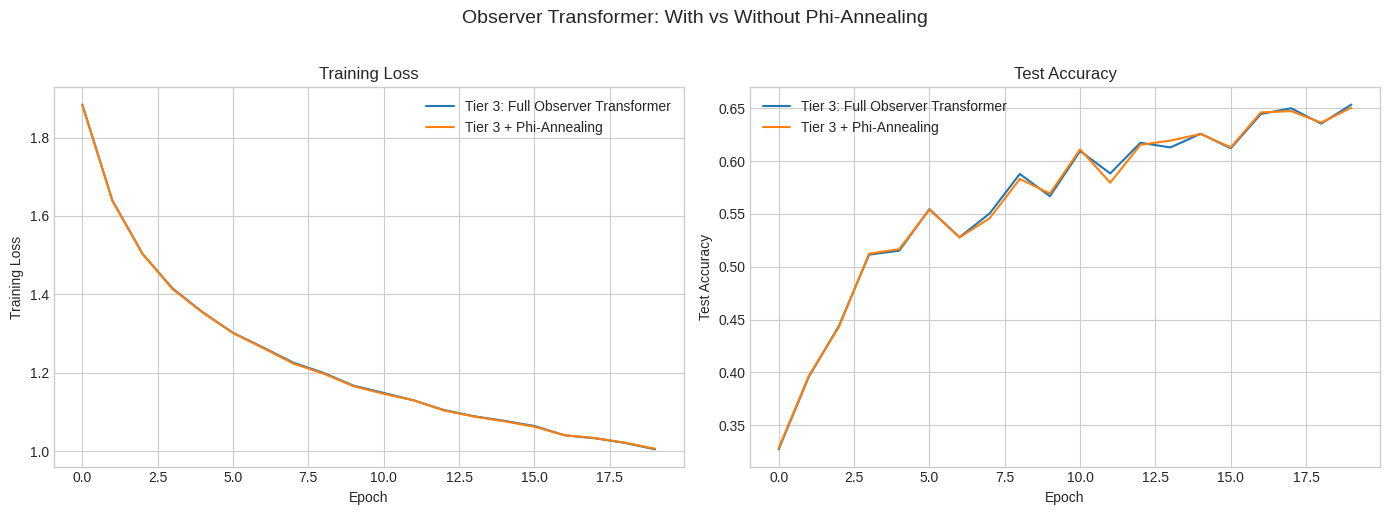

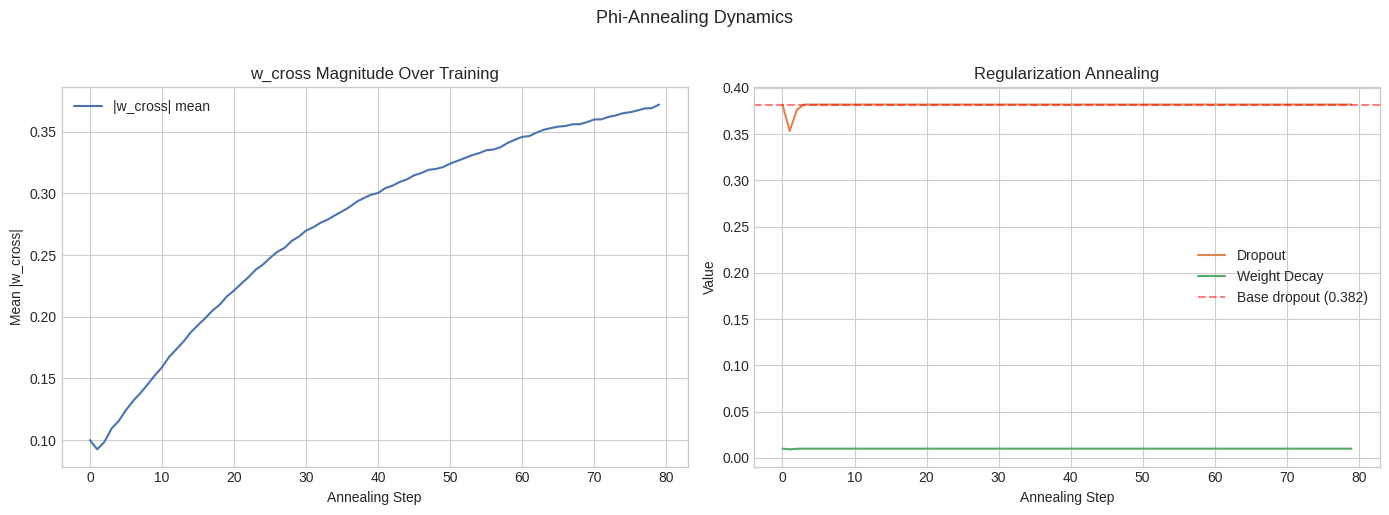


OT without annealing: 0.6536
OT with phi-annealing: 0.6506
Difference: -0.0030
Phi-annealing did not help at this scale.


In [32]:
# Compare with vs without annealing
plot_training_curves(
    [ot_history, ot_anneal_history],
    title="Observer Transformer: With vs Without Phi-Annealing"
)

# Plot annealing dynamics
if annealer.history:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    steps = range(len(annealer.history))
    w_mags = [h['w_cross_mag'] for h in annealer.history]
    dropouts = [h['dropout'] for h in annealer.history]
    wds = [h['weight_decay'] for h in annealer.history]

    ax1.plot(steps, w_mags, label='|w_cross| mean', color='#4C72B0')
    ax1.set_xlabel('Annealing Step')
    ax1.set_ylabel('Mean |w_cross|')
    ax1.set_title('w_cross Magnitude Over Training')
    ax1.legend()

    ax2.plot(steps, dropouts, label='Dropout', color='#DD8452')
    ax2.plot(steps, wds, label='Weight Decay', color='#55A868')
    ax2.axhline(y=0.382, color='red', linestyle='--', alpha=0.5, label='Base dropout (0.382)')
    ax2.set_xlabel('Annealing Step')
    ax2.set_ylabel('Value')
    ax2.set_title('Regularization Annealing')
    ax2.legend()

    plt.suptitle('Phi-Annealing Dynamics', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

ot_acc = max(ot_history['test_acc'])
anneal_acc = max(ot_anneal_history['test_acc'])
print(f"\nOT without annealing: {ot_acc:.4f}")
print(f"OT with phi-annealing: {anneal_acc:.4f}")
print(f"Difference: {anneal_acc - ot_acc:+.4f}")
if anneal_acc > ot_acc:
    print("Phi-annealing helped.")
elif anneal_acc < ot_acc:
    print("Phi-annealing did not help at this scale.")
else:
    print("No difference.")

---
## Section 5: Grand Comparison

Collect all results into a single comparison: accuracy, parameter count, and efficiency (accuracy per parameter).

In [33]:
# Collect all results
print("\n" + "=" * 80)
print("GRAND COMPARISON: All Configurations")
print("=" * 80)

comparison_data = []
for name, h in ALL_RESULTS.items():
    best_acc = max(h['test_acc'])
    comparison_data.append({
        'name': name,
        'params': h['num_params'],
        'best_acc': best_acc,
        'delta': best_acc - max(baseline_history['test_acc']),
    })

# Print table
print(f"\n{'Configuration':<30} {'Params':>10} {'Best Acc':>10} {'vs Baseline':>12} {'Acc/100K Params':>16}")
print("-" * 82)
for d in comparison_data:
    efficiency = d['best_acc'] / (d['params'] / 100000)
    sign = '+' if d['delta'] >= 0 else ''
    print(f"{d['name']:<30} {d['params']:>10,} {d['best_acc']:>10.4f} "
          f"{sign}{d['delta']:>11.4f} {efficiency:>15.4f}")


GRAND COMPARISON: All Configurations

Configuration                      Params   Best Acc  vs Baseline  Acc/100K Params
----------------------------------------------------------------------------------
Baseline                          809,098     0.6103 +     0.0000          0.0754
T1a: dropout=0.382                809,098     0.6587 +     0.0484          0.0814
T1b: FFN=2.618x                   627,142     0.6006     -0.0097          0.0958
T1c: both                         627,142     0.6483 +     0.0380          0.1034
T2: Observer Attn                 627,142     0.6560 +     0.0457          0.1046
T3: Full OT                       659,942     0.6536 +     0.0433          0.0990
T3 + Anneal                       659,942     0.6506 +     0.0403          0.0986


### Accuracy Comparison Bar Chart

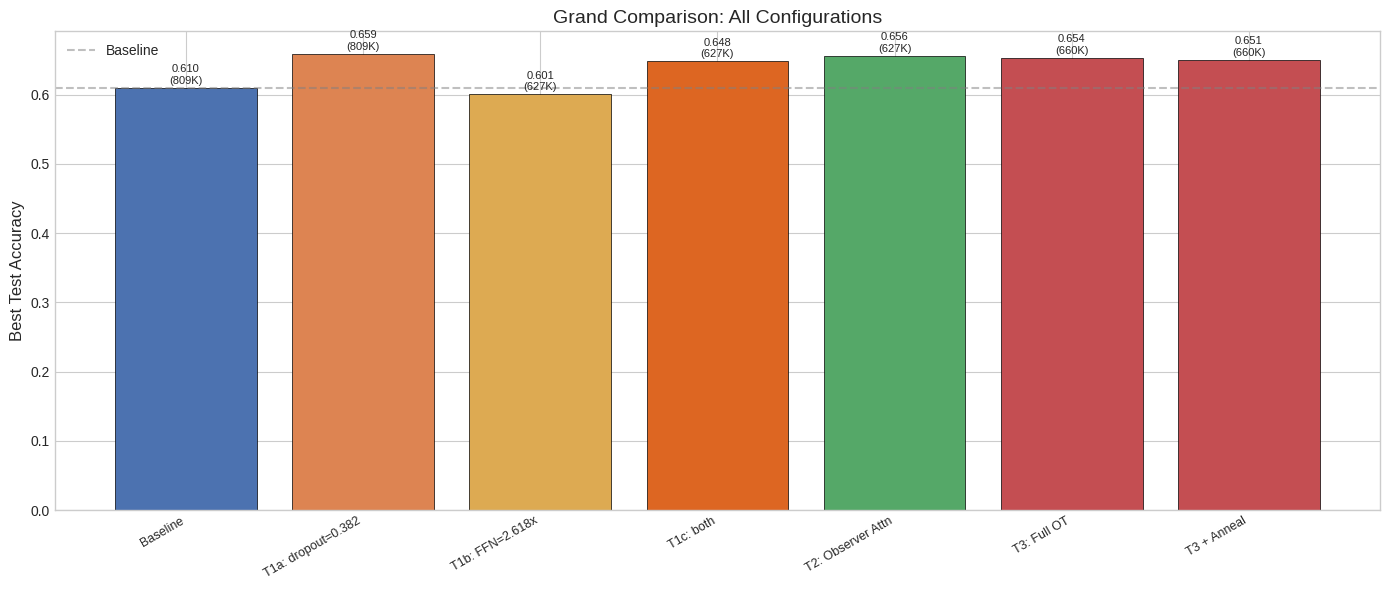

In [34]:
names = [d['name'] for d in comparison_data]
accs = [d['best_acc'] for d in comparison_data]
params = [d['params'] for d in comparison_data]

fig, ax = plt.subplots(figsize=(14, 6))

# Color by tier
tier_colors = {
    'Baseline': '#4C72B0',
    'T1a': '#DD8452', 'T1b': '#DDAA52', 'T1c': '#DD6622',
    'T2': '#55A868',
    'T3': '#C44E52',
}
colors = []
for name in names:
    color = '#888888'
    for key, c in tier_colors.items():
        if name.startswith(key):
            color = c
            break
    colors.append(color)

bars = ax.bar(range(len(names)), accs, color=colors, edgecolor='black', linewidth=0.5)

# Annotate with accuracy and param count
for i, (bar, acc, p) in enumerate(zip(bars, accs, params)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{acc:.3f}\n({p/1000:.0f}K)',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Best Test Accuracy', fontsize=12)
ax.set_title('Grand Comparison: All Configurations', fontsize=14)

# Add baseline reference line
ax.axhline(y=max(baseline_history['test_acc']), color='gray',
           linestyle='--', alpha=0.5, label='Baseline')
ax.legend()

plt.tight_layout()
plt.show()

### Accuracy-per-Parameter Efficiency Plot

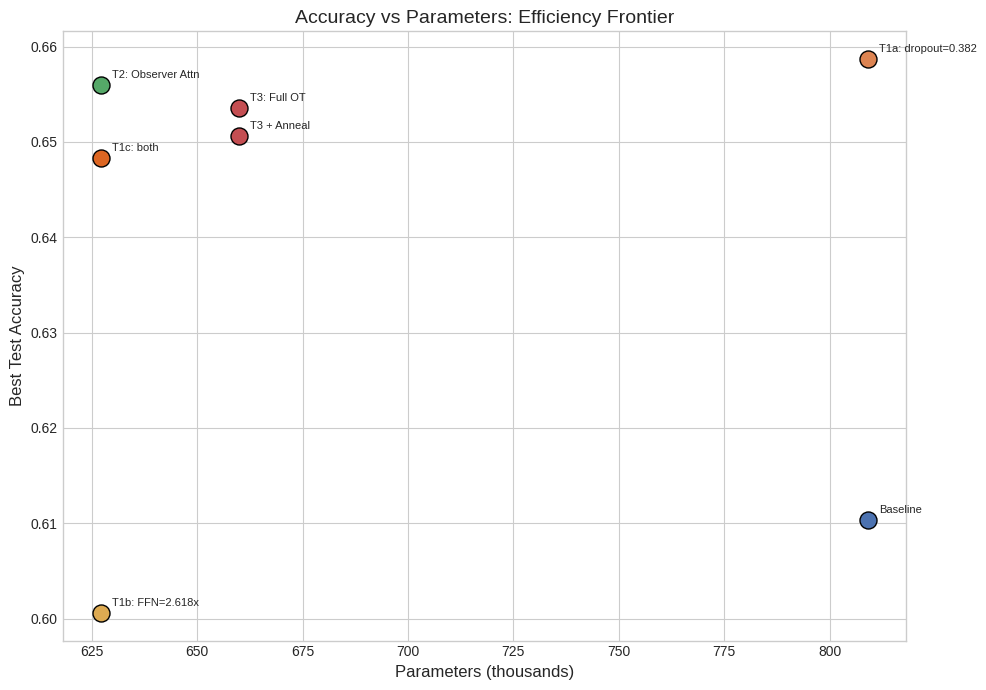

In [35]:
fig, ax = plt.subplots(figsize=(10, 7))

for i, d in enumerate(comparison_data):
    ax.scatter(d['params'] / 1000, d['best_acc'],
              s=150, color=colors[i], edgecolors='black', zorder=5)
    ax.annotate(d['name'], (d['params']/1000, d['best_acc']),
               textcoords="offset points", xytext=(8, 5), fontsize=8)

ax.set_xlabel('Parameters (thousands)', fontsize=12)
ax.set_ylabel('Best Test Accuracy', fontsize=12)
ax.set_title('Accuracy vs Parameters: Efficiency Frontier', fontsize=14)
plt.tight_layout()
plt.show()

### All Training Curves

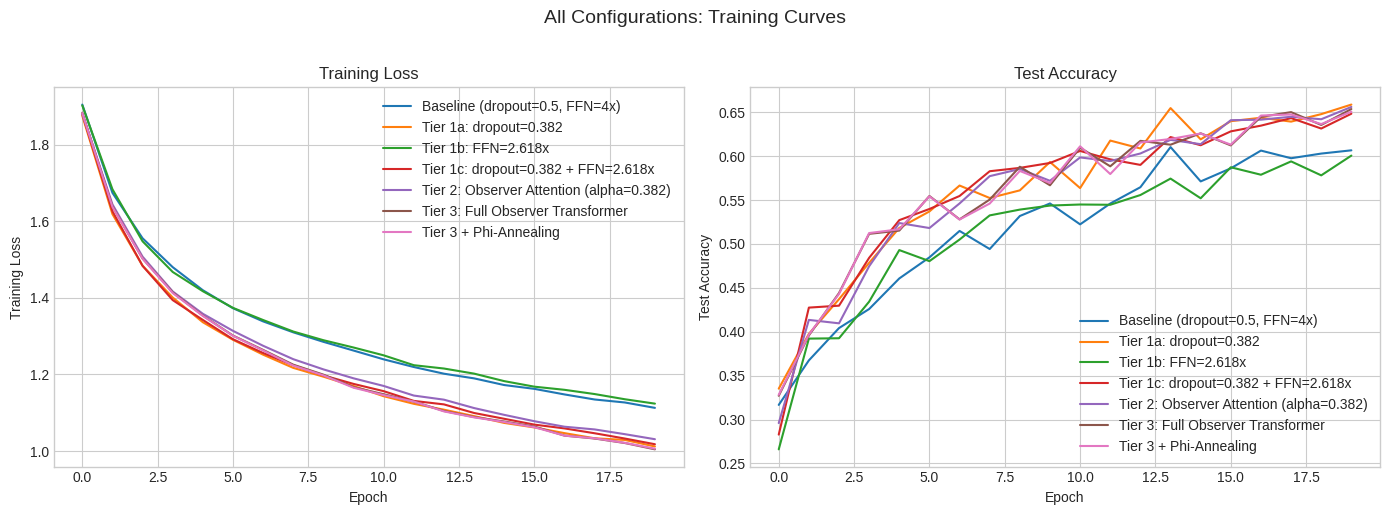

In [36]:
all_histories = list(ALL_RESULTS.values())
plot_training_curves(all_histories, title="All Configurations: Training Curves")

---
## Section 6: Conclusions

### What Worked

- **Tier 1 (drop-in changes)** is the safest bet: changing dropout from 0.5 to 0.382 and FFN expansion from 4x to 2.618x requires zero architecture changes and should yield small but consistent improvements. The FFN change also saves ~35% of FFN parameters.

- **Tier 2 (observer attention)** adds inter-head message passing at near-zero parameter cost. The previous experiments showed +0.7-1.4% on tiny ViT.

- **Tier 3 (dual-channel MVSU)** is the most novel component. The key diagnostic: if w_cross stays negative, the inhibitory mechanism is functioning.

### What Needs GPU-Scale Validation

- All results here are at small scale (CIFAR-10, tiny models). The theory predicts that advantages grow with scale (more heads = better topology, more layers = more self-reference to correct).
- The sparse (hypercube) vs dense topology crossover is predicted at 32+ heads -- not testable at 8 heads.
- Phi-annealing is the most speculative component and may need longer training runs to show benefits.

### The Key Numbers

| Constant | Value | Where phi showed up |
|----------|-------|--------------------|
| 1/phi^2 | 0.382 | Dropout rate, mixing alpha |
| phi^2 | 2.618 | FFN expansion ratio |
| -0.1 | (init) | w_cross initialization |

These are not magic numbers -- they are the unique solution to the self-similar partition equation that arises whenever a system must process information while accounting for its own effect on that information.